In [1]:
import h5py
import numpy as np
from illustris_python.groupcat import loadSingle, loadHeader
import illustris_python as il
import matplotlib.pyplot as plt
import matplotlib 
import mpl_toolkits.mplot3d as mpl3
from matplotlib.gridspec import GridSpec
import requests
import pandas as pd
import pickle
from tqdm import tqdm
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Constante de Hubble en unidades de [km/s / Mpc]:
H0 = 67.74
h = H0 / 100 

# Tamaño del box de simulación
box_size = 204.98124  # Mpc/h

# Path de las simulaciones TNG300-1 en este directorio:
myBasePath = '../sims.TNG/TNG300-1/output' 

In [3]:
link_halo_subhalos_z0 = pd.read_csv('link_halo_subhalos_z0_halo2.dat', sep=' ')

# PASO 1: EXTRAER INFORMACIÓN DE LAS TRAYECTORIAS

In [10]:
hdf5_file = h5py.File('data_tree_halo2.hdf5', 'r')

In [9]:
hdf5_file.close()

In [12]:
hdf5_file['halo_2'].keys()

<KeysViewHDF5 ['m200', 'pos_x', 'pos_y', 'pos_z', 'r200', 'snapshots', 'subhalo_17908', 'subhalo_17909', 'subhalo_17910', 'subhalo_17911', 'subhalo_17912', 'subhalo_17913', 'subhalo_17914', 'subhalo_17915', 'subhalo_17916', 'subhalo_17917', 'subhalo_17918', 'subhalo_17919', 'subhalo_17920', 'subhalo_17921', 'subhalo_17922', 'subhalo_17923', 'subhalo_17924', 'subhalo_17925', 'subhalo_17926', 'subhalo_17927', 'subhalo_17928', 'subhalo_17929', 'subhalo_17930', 'subhalo_17931', 'subhalo_17932', 'subhalo_17933', 'subhalo_17934', 'subhalo_17935', 'subhalo_17936', 'subhalo_17937', 'subhalo_17938', 'subhalo_17939', 'subhalo_17940', 'subhalo_17941', 'subhalo_17942', 'subhalo_17943', 'subhalo_17944', 'subhalo_17945', 'subhalo_17946', 'subhalo_17947', 'subhalo_17948', 'subhalo_17949', 'subhalo_17950', 'subhalo_17951', 'subhalo_17952', 'subhalo_17953', 'subhalo_17954', 'subhalo_17955', 'subhalo_17956', 'subhalo_17957', 'subhalo_17958', 'subhalo_17959', 'subhalo_17960', 'subhalo_17961', 'subhalo_17

In [20]:
hdf5_file['halo_2/subhalo_17915/Subhalo_gas_T']

<HDF5 dataset "Subhalo_gas_T": shape (92, 3), type "<f8">

In [13]:
info_list = []

with h5py.File('data_tree_halo2.hdf5', 'r') as hdf5_file:

    # Iteramos por cada fila del DataFrame de subhalos linkeados a un halo
    for idx, subhalo_row in tqdm(link_halo_subhalos_z0.iterrows(),
                                 total=len(link_halo_subhalos_z0),
                                 desc='Subhalos'):

        # --- Información del halo desde el DataFrame ---
        halo_id_z0 = int(subhalo_row['halo_id_z0'])
        halo_m200_z0 = subhalo_row['halo_m200_z0'] # Msun/h
        halo_r200_z0 = subhalo_row['halo_r200_z0'] # cMpc/h
        halo_pos_x_z0 = subhalo_row['halo_pos_x_z0'] # cMpc/h
        halo_pos_y_z0 = subhalo_row['halo_pos_y_z0'] # cMpc/h
        halo_pos_z_z0 = subhalo_row['halo_pos_z_z0'] # cMpc/h
        halo_vel_x_z0 = subhalo_row['halo_vel_x_z0'] # km/s
        halo_vel_y_z0 = subhalo_row['halo_vel_y_z0'] # km/s
        halo_vel_z_z0 = subhalo_row['halo_vel_z_z0'] # km/s
        
        # --- Información del subhalo desde el DataFrame ---
        sub_id_z0 = int(subhalo_row['sub_id_z0'])       
        sub_mstar_z0 = subhalo_row['sub_mstar_z0'] # Msun/h
        sub_pos_x_z0 = subhalo_row['sub_pos_x_z0'] # cMpc/h
        sub_pos_y_z0 = subhalo_row['sub_pos_y_z0'] # cMpc/h
        sub_pos_z_z0 = subhalo_row['sub_pos_z_z0'] # cMpc/h
        sub_vel_x_z0 = subhalo_row['sub_vel_x_z0'] # km/s
        sub_vel_y_z0 = subhalo_row['sub_vel_y_z0'] # km/s
        sub_vel_z_z0 = subhalo_row['sub_vel_z_z0'] # km/s
        sub_dist_3d_z0 = subhalo_row['sub_dist_3d_z0'] # cMpc/h

        # --- Información del halo desde el HDF5 ---
        halo_group = hdf5_file[f'halo_{halo_id_z0}']
        
        halo_m200 = halo_group['m200'][:] # Msun/h
        halo_r200 = halo_group['r200'][:] # cMpc/h
        halo_pos_x = halo_group['pos_x'][:] # cMpc/h
        halo_pos_y = halo_group['pos_y'][:] # cMpc/h
        halo_pos_z = halo_group['pos_z'][:] # cMpc/h
                
        # --- Información del subhalo desde el HDF5 ---
        subhalo_key = f'subhalo_{sub_id_z0}'
        subhalo_group = halo_group[subhalo_key]
        
        sub_pos_x = subhalo_group['pos_x'][:] # cMpc/h
        sub_pos_y = subhalo_group['pos_y'][:] # cMpc/h
        sub_pos_z = subhalo_group['pos_z'][:] # cMpc/h
        
        sub_gas_mass_fix = subhalo_group['Subhalo_gas_mass'][:,0] #
        halo_gas_mass_fix = subhalo_group['Halo_gas_mass'][:,0] #
        
        sub_gas_mass_2hmr = subhalo_group['Subhalo_gas_mass'][:,1] #
        halo_gas_mass_2hmr = subhalo_group['Halo_gas_mass'][:,1] #
        
        sub_gas_mass_b23 = subhalo_group['Subhalo_gas_mass'][:,2] #
        halo_gas_mass_b23 = subhalo_group['Halo_gas_mass'][:,2] #
        
        sub_gas_T = subhalo_group['Subhalo_gas_T'][:,0] #
        halo_gas_T = subhalo_group['Halo_gas_T'][:,0] #
        
        # ---- RECORREMOS LA TRAYECTORIA DEL SUBHALO ---
        
        # Para evitar errores porque la galaxia "exista" menos que el halo
        min_len = min(len(sub_pos_x), len(halo_r200), len(halo_pos_x))
        
        # Distancia 3D del subhalo al centro del halo para todos los snaps
        sub_dist_3d = np.sqrt((sub_pos_x[:min_len] - halo_pos_x[:min_len])**2 +
                              (sub_pos_y[:min_len] - halo_pos_y[:min_len])**2 +
                              (sub_pos_z[:min_len] - halo_pos_z[:min_len])**2) # cMpc/h
        
        # Distancia 2D del subhalo al centro del halo en z=0
        sub_dist_2d_z0 = np.sqrt((sub_pos_x_z0 - halo_pos_x_z0)**2 +
                                 (sub_pos_y_z0 - halo_pos_y_z0)**2) # cMpc/h
            
        # Vector posición relativo (del halo al subhalo)
        rx_rel_z0 = sub_pos_x_z0 - halo_pos_x_z0 # cMpc/h
        ry_rel_z0 = sub_pos_y_z0 - halo_pos_y_z0 # cMpc/h
        rz_rel_z0 = sub_pos_z_z0 - halo_pos_z_z0 # cMpc/h

        # Vector velocidad relativa (del halo al subhalo)
        vx_rel_z0 = sub_vel_x_z0 - halo_vel_x_z0 # km/s
        vy_rel_z0 = sub_vel_y_z0 - halo_vel_y_z0 # km/s
        vz_rel_z0 = sub_vel_z_z0 - halo_vel_z_z0 # km/s

        # Velocidad radial del subhalo respecto al halo a z=0
        # ΔV * r{versor} + H0*d / h ---> ahora queda en km/s 

        sub_velrad_z0 = ((vx_rel_z0*rx_rel_z0 + vy_rel_z0*ry_rel_z0 + vz_rel_z0*rz_rel_z0) / sub_dist_3d_z0) + (100. * sub_dist_3d_z0)
          
        # Entradas y salidas de r200
        snap_out = []
        snap_in = []
        
        # Suponemos que 'True' es estar dentro de r200 y 'False' fuera
        condition = sub_dist_3d[:min_len] < halo_r200[:min_len]

        # Vemos cual es el estado a z=0
        state_post = 'in' if condition[0] else 'out'

        # Ahora vemos cual es el estado para z mayores
        for i, result in enumerate(condition):

            state_prev = 'in' if result else 'out'
            snapshot = 99 - i

            if state_post != state_prev:
                if state_prev == 'out':
                    snap_in.append(snapshot)  # Pasó de fuera a dentro (al mirar hacia adelante en el tiempo)
                else:
                    snap_out.append(snapshot)  # Pasó de dentro a fuera

            # Actualizamos
            state_post = state_prev
            
            # --- Guardar info en DataFrame ---
            info = pd.DataFrame({
                'halo_id_z0': [halo_id_z0],
                'halo_m200_z0': [halo_m200_z0],
                'halo_r200_z0': [halo_r200_z0],
                'halo_r200': [halo_r200],
                'halo_posx_z0': [halo_pos_x_z0],
                'halo_posy_z0': [halo_pos_y_z0],
                'halo_posz_z0': [halo_pos_z_z0],
                'halo_velx_z0': [halo_vel_x_z0],
                'halo_vely_z0': [halo_vel_y_z0],
                'halo_velz_z0': [halo_vel_z_z0],
                'sub_id_z0': [sub_id_z0],
                'sub_dist_2d_z0': [sub_dist_2d_z0],
                'sub_dist_3d_z0': [sub_dist_3d_z0],
                'sub_dist_3d': [np.round(sub_dist_3d, 5)],
                'sub_posx_z0': [sub_pos_x_z0],
                'sub_posy_z0': [sub_pos_y_z0],
                'sub_posz_z0': [sub_pos_z_z0],
                'sub_velx_z0': [sub_vel_x_z0],
                'sub_vely_z0': [sub_vel_y_z0],
                'sub_velz_z0': [sub_vel_z_z0],
                'sub_velrad_z0': [sub_velrad_z0],
                'snap_in': [snap_in],
                'snap_out': [snap_out],
                'sub_gas_mass_fix': [sub_gas_mass_fix],
                'halo_gas_mass_fix': [halo_gas_mass_fix],
                'sub_gas_mass_2hmr': [sub_gas_mass_2hmr],
                'halo_gas_mass_2hmr': [halo_gas_mass_2hmr],
                'sub_gas_mass_b23': [sub_gas_mass_b23],
                'halo_gas_mass_b23': [halo_gas_mass_b23],
                'halo_gas_T': [halo_gas_T]
            })

        info_list.append(info)

Subhalos: 100%|██████████| 200/200 [00:36<00:00,  5.43it/s]


In [14]:
# Concatenar todos los DataFrames
df = pd.concat(info_list, ignore_index=True)

In [15]:
len(df)

200

In [56]:
n_sign_change = np.zeros(len(df))
for i in range(len(df)):
    try:
        snap_in = np.min(df['snap_in'].iloc[i])
        delta_d = df['sub_dist_3d'].iloc[i][1:] - df['sub_dist_3d'].iloc[i][:-1] # >0: se va acercando, <0: se esta alejando
        delta_d = delta_d[:(99-snap_in)]
        sign_change = np.where(np.sign(delta_d[1:]*delta_d[:-1]) < 0)[0]
        n_sign_change[i] = len(sign_change)
    except:
        n_sign_change[i] = 0


In [57]:
df['n_sign_change'] = n_sign_change

In [58]:
n_sign_change

array([ 0.,  1.,  1.,  4.,  1.,  2.,  0.,  0.,  3.,  1.,  3.,  2.,  0.,
        1.,  1.,  0.,  5.,  5.,  0.,  1.,  2.,  0.,  1.,  5.,  1.,  4.,
        1.,  1.,  6.,  2.,  5.,  5.,  1., 24.,  7.,  1.,  1.,  1.,  4.,
        6.,  1.,  1.,  4.,  3.,  7.,  0., 15.,  1.,  1.,  4.,  1.,  1.,
        5.,  4.,  0.,  4.,  7.,  7.,  0.,  0.,  1.,  4., 18.,  4.,  4.,
        1.,  2.,  6.,  2.,  2.,  1.,  4.,  1.,  9.,  0.,  0.,  1.,  1.,
        0.,  4.,  1.,  2.,  4.,  3.,  3.,  4.,  1., 10.,  4.,  3.,  1.,
        1.,  3.,  1.,  1.,  1.,  2.,  3.,  2.,  1.,  1.,  4.,  3.,  1.,
        7.,  2., 16.,  1.,  2.,  1.,  6.,  1.,  1.,  2.,  4.,  1.,  0.,
        4.,  2.,  4.,  4.,  2.,  4.,  7.,  3.,  4.,  4., 17.,  5.,  4.,
        5.,  7.,  4.,  0.,  0.,  4.,  4.,  0.,  1.,  1.,  0.,  0.,  9.,
        9.,  2.,  1.,  2.,  3.,  7.,  1.,  6., 15.,  2.,  3.,  1.,  2.,
        2.,  5.,  2.,  2.,  2.,  4.,  2.,  1.,  0.,  1.,  1.,  4.,  6.,
        2.,  2.,  4., 20.,  1.,  6.,  1.,  1.,  4.,  1.,  3.,  4

In [50]:
df.columns

Index(['halo_id_z0', 'halo_m200_z0', 'halo_r200_z0', 'halo_r200',
       'halo_posx_z0', 'halo_posy_z0', 'halo_posz_z0', 'halo_velx_z0',
       'halo_vely_z0', 'halo_velz_z0', 'sub_id_z0', 'sub_dist_2d_z0',
       'sub_dist_3d_z0', 'sub_dist_3d', 'sub_posx_z0', 'sub_posy_z0',
       'sub_posz_z0', 'sub_velx_z0', 'sub_vely_z0', 'sub_velz_z0',
       'sub_velrad_z0', 'snap_in', 'snap_out', 'sub_gas_mass_fix',
       'halo_gas_mass_fix', 'sub_gas_mass_2hmr', 'halo_gas_mass_2hmr',
       'sub_gas_mass_b23', 'halo_gas_mass_b23', 'halo_gas_T', 'orbit_type',
       'n_sign_change'],
      dtype='object')

In [37]:
np.min(df['snap_in'].iloc[1])

89

0.0
1.0
2.0
3.0
4.0
5.0
6.0
7.0
9.0
10.0
15.0
16.0
17.0
18.0
20.0
24.0


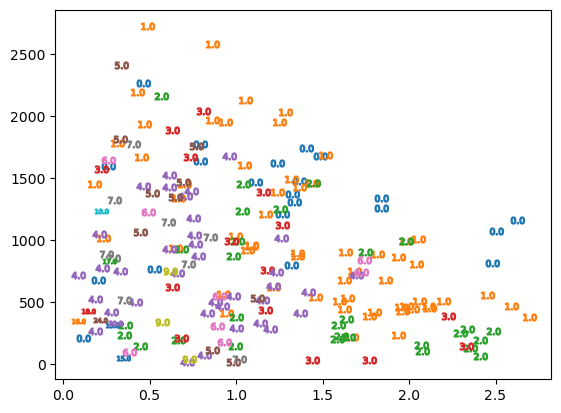

In [73]:
for i in np.unique(n_sign_change):
    print(i)
    aux_ind = np.where(n_sign_change == i)[0]
    plt.scatter(np.asarray(df['sub_dist_2d_z0'])[aux_ind], np.abs(np.asarray(df['sub_velrad_z0'])[aux_ind]), marker = f'${i}$', s = 100)

#aux_ind = np.where(n_sign_change == 1)[0]
#plt.scatter(np.asarray(df['sub_dist_2d_z0'])[aux_ind], np.abs(np.asarray(df['sub_velrad_z0'])[aux_ind]), marker = '$1$')

#aux_ind = np.where(n_sign_change == 2)[0]
#plt.scatter(np.asarray(df['sub_dist_2d_z0'])[aux_ind], np.abs(np.asarray(df['sub_velrad_z0'])[aux_ind]), marker = '$2$')
plt.savefig('n_sign_change_halo2.pdf')

# PASO 2: CLASIFICAR TRAYECTORIAS (CL, BS, RIN, IN, ITL)

In [21]:
# Agregamos al DataFrame la columna con la clasificación de órbitas

for index, row in df.iterrows():
    
    sub_dist_3d_z0 = row['sub_dist_3d_z0']
    sub_velrad_z0 = row['sub_velrad_z0']
    snap_in = row['snap_in']
    snap_out = row['snap_out']
    halo_r200_z0 = row['halo_r200_z0']
    
    # Inicializamos orbit_type en -1 (fuera de todas las categorías)
    orbit_type = -1

                                                            # Cluster members (CL)
    
    # Si las entradas y salidas de r200 son mayor a 2
    if len(snap_in)+len(snap_out)>2:
        
        orbit_type = 1
    
    # Si entró una vez, nunca salió, pero esa entrada fue antes de 2Gyrs
    if len(snap_in)>0 and len(snap_in)==1 and len(snap_out)==0 and snap_in[-1]<86:
        
        orbit_type = 1
    
    # Si nunca entró y nunca salió (la central)
    if len(snap_in)==0 and len(snap_out)==0 and sub_dist_3d_z0<halo_r200_z0:
        
        orbit_type = 1
    
    # Si entró y salió y volvió a entrar sin importar cuando
    if len(snap_in)>0 and len(snap_out)>0 and snap_in[-1] > snap_out[-1]:
    
        orbit_type = 1
        
                                                            # Backsplash (BS)
    
    # Se encuentra fuera de r200 y entró y salió una única vez
    if sub_dist_3d_z0>halo_r200_z0 and len(snap_in)==1 and len(snap_out)==1:
        
        orbit_type = 2
        
                                                            # Recent infallers (RIN)
    
    # Entró, se encuentra dentro a z=0 y la primera vez que entró fue dentro de los últimos 2 Gyrs
    if len(snap_in)==1 and sub_dist_3d_z0<halo_r200_z0 and snap_in[0]>=86:
        
        orbit_type = 3
        
                                                            # Infall galaxies (IN)
    
    # Se encuentra fuera, nunca entró y su velocidad radial respecto al grupo es negativa
    if sub_dist_3d_z0>halo_r200_z0 and len(snap_in)==0 and sub_velrad_z0<0.:
    
        orbit_type = 4

                                                            # Interlopers (ITL)
    
    # Se encuentra fuera, nunca entró y su velocidad radial respecto al grupo es positiva
    if sub_dist_3d_z0>halo_r200_z0 and len(snap_in)==0 and sub_velrad_z0>0.:
        
        orbit_type = 5

    # Asignamos orbit_type a la fila actual
    df.at[index, 'orbit_type'] = orbit_type

In [26]:
df['orbit_type']

0      1.0
1      3.0
2      2.0
3      1.0
4      2.0
      ... 
195    1.0
196    3.0
197    1.0
198    3.0
199    1.0
Name: orbit_type, Length: 200, dtype: float64

# PASO 3: VERIFICAR ALGUNAS TRAYECTORIAS

In [60]:
cl = df[df['orbit_type'] == 1.].sample(n=5, replace = False)
bs = df[df['orbit_type'] == 2.].sample(n=5, replace = False)
rin = df[df['orbit_type'] == 3.].sample(n=5, replace = False)
inn = df[df['orbit_type'] == 4.].sample(n=5, replace = False)
#itl = df[df['orbit_type'] == 5.].sample(n=5, replace = True)

In [70]:
cl.columns

Index(['halo_id_z0', 'halo_m200_z0', 'halo_r200_z0', 'halo_r200',
       'halo_posx_z0', 'halo_posy_z0', 'halo_posz_z0', 'halo_velx_z0',
       'halo_vely_z0', 'halo_velz_z0', 'sub_id_z0', 'sub_dist_2d_z0',
       'sub_dist_3d_z0', 'sub_dist_3d', 'sub_posx_z0', 'sub_posy_z0',
       'sub_posz_z0', 'sub_velx_z0', 'sub_vely_z0', 'sub_velz_z0',
       'sub_velrad_z0', 'snap_in', 'snap_out', 'sub_gas_mass_fix',
       'halo_gas_mass_fix', 'sub_gas_mass_2hmr', 'halo_gas_mass_2hmr',
       'sub_gas_mass_b23', 'halo_gas_mass_b23', 'halo_gas_T', 'orbit_type',
       'n_sign_change'],
      dtype='object')

In [74]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

In [ ]:
# Define custom handles


fig, ax = plt.subplots()
# Create legend using the handles
ax.legend(handles=legend_elements, loc='upper right')

In [ ]:
colors = {'inn': '#5f4b8b', 'rin': '#3d9970', 'bs': '#ff851b', 'cl': '#b91228', 'itl': 'grey'}
datasets = {'cl': cl, 'rin': rin, 'bs': bs, 'inn': inn}
n_rows = len(cl)

fig, axes = plt.subplots(n_rows, 5, figsize=(15, 3 * n_rows), sharex=True, sharey=True)

for col_idx, (key, dataframe) in enumerate(datasets.items()):
    color = colors[key]  
    
    for row_idx, (r200_list, dist, indice, subhalo_gas_mass, halo_gas_mass, snap_in) in enumerate(zip(dataframe['halo_r200'], dataframe['sub_dist_3d'], dataframe['sub_id_z0'], 
                                                                           dataframe['sub_gas_mass_fix'], dataframe['halo_gas_mass_fix'], dataframe['snap_in'])):
        ax = axes[row_idx, col_idx] 
        
        min_len = min(len(r200_list), len(dist))
        time = np.arange(99, 99 - min_len, -1)

        ax.plot(time, dist[:min_len]/r200_list[:min_len], color='k', ls='-', lw=1)
        #ax.plot(time, dist[:min_len], color=color, ls='-', lw=2)
        ax.plot(time, halo_gas_mass[:min_len] / halo_gas_mass[0], color=color, ls=':', lw=2)
        ax.plot(time, subhalo_gas_mass[:min_len] / np.max(subhalo_gas_mass), color=color, ls='--', lw=2)
        #ax.plot(time, halo_gas_T[:min_len] / halo_gas_T[0], color=color, ls='-.', lw=2)
        
        
        #delta_d = dist[1:] - dist[:-1]
        #if len(snap_in) > 0: 
        #    snap_in = np.min(snap_in)
        #    delta_d = delta_d[:(99-snap_in)]
        #    sign_change = np.where(np.sign(delta_d[1:]*delta_d[:-1]) < 0)[0]
        #    if len(sign_change) > 0:
        #        for dt in sign_change:
        #            ax.axvline(x = time[dt], color='magenta', ls='-.', lw=2)

        if row_idx == 0:  
            ax.set_title(key.upper(), color=color, fontsize=15)
            
        if row_idx == 4:  
            ax.set_xlabel('Snapshot', fontsize=12)

        if col_idx == 0: 
            ax.set_ylabel(f'Distance / R200', fontsize=12)
        
        ax.set_ylim(0, 7.5)
        #ax.set_xlim(95, 100)
        #ax.text(90, 6, f'{indice}')

legend_elements = [
    Line2D([0], [0], color='black', lw=2, label='Halo Gas Fix', ls = ':'),
    Line2D([0], [0], color='black', lw=2, label='Subhalo Gas Fix', ls = '--')
]
ax.legend(handles=legend_elements, loc='upper right')
fig.tight_layout()
plt.show()

plt.savefig('Trayectorias_halo2.pdf')

# PASO 4: CALCULAR $\sigma$ EN LAS TRES DIRECCIONES USANDO 'CL' Y 'RIN'

### Métodos para calcular la dispersión de velocidades

In [9]:
def biweight_std(data):
    
    median = np.nanmedian(data)
    mad = np.nanmedian(np.abs(data - median))
    n = len(data)
    c = 9.
    biweight_num = 0.
    biweight_den = 0.
    
    for x in data:
        
        u = (x - median) / (c * mad)
        
        if abs(u)<1.:
            
            biweight_num += (((x-median)**2) * ((1 - (u**2.))**4.))
            biweight_den += (1 - (u**2.))*(1 - 5*(u**2.))
    
    biweight_numerator = np.sqrt(biweight_num)
    biweight_denominator = np.abs(biweight_den)
        
    biweight_std = np.sqrt(n) * (biweight_numerator/biweight_denominator) 
    
    return biweight_std

In [10]:
def gapper_std(data):
    
    n = len(data)
    gapper_sum = 0.
    
    for i in range(n-1):
       
        j = i+1
        g = data[i+1] - data[i]
        w = j*(n-j)
        gapper_sum += w * g 

    gapper_std = (np.sqrt(np.pi) / (n * (n - 1))) * gapper_sum
    
    return gapper_std

### Sigma z

In [11]:
# Creamos la nueva columna para el sigma
df['halo_sigma_z'] = np.nan
link_halo_subhalos_z0['halo_sigma_z'] = np.nan

# Filtramos solo las filas con orbit_type = 1 o 3 (CL o RIN)
mask_orbit = df['orbit_type'].isin([1, 3])
df_filtered = df[mask_orbit].copy()

# Agrupar por halo_id_z0
for halo_id, group in df_filtered.groupby('halo_id_z0'):
    
    # Calcular las velocidades relativas
    vel_z = sorted(group['halo_velz_z0'] - group['sub_velz_z0'])

    # Verificaciones
    if len(vel_z) == 0:
        print(f"Grupo vacío para halo_id_z0 = {halo_id}")
        continue

    if np.any(np.isnan(vel_z)):
        print(f"Hay NaN en velz para halo_id_z0 = {halo_id}")
        continue

    # Calcular sigma según la cantidad de elementos
    if len(vel_z) <= 15:
        sigma_z = gapper_std(np.array(vel_z))  # km/s
    else:
        sigma_z = biweight_std(np.array(vel_z))  # km/s

    # Asignar sigma_z a TODAS las filas de ese halo_id_z0 (no solo las filtradas)
    df.loc[df['halo_id_z0'] == halo_id, 'halo_sigma_z'] = sigma_z
    link_halo_subhalos_z0.loc[link_halo_subhalos_z0['halo_id_z0'] == halo_id, 'halo_sigma_z'] = sigma_z

### Sigma y

In [12]:
# Creamos la nueva columna para el sigma
df['halo_sigma_y'] = np.nan
link_halo_subhalos_z0['halo_sigma_y'] = np.nan

# Filtramos solo las filas con orbit_type = 1 o 3 (CL o RIN)
mask_orbit = df['orbit_type'].isin([1, 3])
df_filtered = df[mask_orbit].copy()

# Agrupar por halo_id_z0
for halo_id, group in df_filtered.groupby('halo_id_z0'):
    
    # Calcular las velocidades relativas
    vel_y = sorted(group['halo_vely_z0'] - group['sub_vely_z0'])

    # Verificaciones
    if len(vel_y) == 0:
        print(f"Grupo vacío para halo_id_z0 = {halo_id}")
        continue

    if np.any(np.isnan(vel_y)):
        print(f"Hay NaN en vely para halo_id_z0 = {halo_id}")
        continue

    # Calcular sigma según la cantidad de elementos
    if len(vel_y) <= 15:
        sigma_y = gapper_std(np.array(vel_y))  # km/s
    else:
        sigma_y = biweight_std(np.array(vel_y))  # km/s

    # Asignar sigma_y a TODAS las filas de ese halo_id_z0 (no solo las filtradas)
    df.loc[df['halo_id_z0'] == halo_id, 'halo_sigma_y'] = sigma_y
    link_halo_subhalos_z0.loc[link_halo_subhalos_z0['halo_id_z0'] == halo_id, 'halo_sigma_y'] = sigma_y

### Sigma x

In [13]:
# Creamos la nueva columna para el sigma
df['halo_sigma_x'] = np.nan
link_halo_subhalos_z0['halo_sigma_x'] = np.nan

# Filtramos solo las filas con orbit_type = 1 o 3 (CL o RIN)
mask_orbit = df['orbit_type'].isin([1, 3])
df_filtered = df[mask_orbit].copy()

# Agrupar por halo_id_z0
for halo_id, group in df_filtered.groupby('halo_id_z0'):
    
    # Calcular las velocidades relativas
    vel_x = sorted(group['halo_velx_z0'] - group['sub_velx_z0'])

    # Verificaciones
    if len(vel_x) == 0:
        print(f"Grupo vacío para halo_id_z0 = {halo_id}")
        continue

    if np.any(np.isnan(vel_x)):
        print(f"Hay NaN en velx para halo_id_z0 = {halo_id}")
        continue

    # Calcular sigma según la cantidad de elementos
    if len(vel_x) <= 15:
        sigma_x = gapper_std(np.array(vel_x))  # km/s
    else:
        sigma_x = biweight_std(np.array(vel_x))  # km/s

    # Asignar sigma_x a TODAS las filas de ese halo_id_z0 (no solo las filtradas)
    df.loc[df['halo_id_z0'] == halo_id, 'halo_sigma_x'] = sigma_x
    link_halo_subhalos_z0.loc[link_halo_subhalos_z0['halo_id_z0'] == halo_id, 'halo_sigma_x'] = sigma_x

# PASO 5: GUARDAR LA INFORMACIÓN FINAL IMPORTANTE

In [14]:
# Vamos a crear un nuevo DataFrame con la información de las trayectorias
data_orbits = pd.DataFrame()

data_orbits['halo_id_z0'] = df['halo_id_z0']
data_orbits['sub_id_z0'] = df['sub_id_z0']
data_orbits['halo_m200_z0'] = df['halo_m200_z0']
data_orbits['halo_r200_z0'] = df['halo_r200_z0']
data_orbits['orbit_type'] = df['orbit_type']
data_orbits['sub_dist_2d_z0'] = df['sub_dist_2d_z0']
data_orbits['sub_dist_3d_z0'] = df['sub_dist_3d_z0']
data_orbits['snap_in'] = df['snap_in']
data_orbits['snap_out'] = df['snap_out']
data_orbits['sub_r_proj'] = round(df['sub_dist_2d_z0'] / df['halo_r200_z0'], 5)
# Velocidad = Velocidad peculiar + Flujo de Hubble (H0*dist)
data_orbits['sub_v_los_z'] = round(np.abs((df['halo_velz_z0'] + 100. * df['halo_posz_z0']) - (df['sub_velz_z0'] + 100. * df['sub_posz_z0'])) / df['halo_sigma_z'], 5)
data_orbits['sub_v_los_y'] = round(np.abs((df['halo_vely_z0'] + 100. * df['halo_posy_z0']) - (df['sub_vely_z0'] + 100. * df['sub_posy_z0'])) / df['halo_sigma_y'], 5)
data_orbits['sub_v_los_x'] = round(np.abs((df['halo_velx_z0'] + 100. * df['halo_posx_z0']) - (df['sub_velx_z0'] + 100. * df['sub_posx_z0'])) / df['halo_sigma_x'], 5)

In [15]:
data_orbits.to_csv('data_orbits_sin_itl.dat', sep='\t', index=False)
link_halo_subhalos_z0.to_csv('link_halo_subhalos_z0.dat', sep='\t', index=False)